In [5]:
import numpy as np
import matplotlib.pyplot as plt
import json
import sys
import pathlib

source_dir = pathlib.Path.cwd().parent / 'software' / 'source'
if str(source_dir) not in sys.path:
    sys.path.append(str(source_dir))

from qick_emu import QickEmu
from qick import QickConfig
from qick.asm_v2 import AveragerProgramV2

# Define paths
REPO_ROOT = pathlib.Path.cwd().parent

CFG_PATH = REPO_ROOT / "notebooks" / "qick_config_216.json"

In [6]:
emu = QickEmu(str(CFG_PATH)) 
soccfg = emu.soccfg

# 3. Define the QICK Program
GEN_CH = 0
RO_CH = 0
FREQ = 100

QICK library version mismatch: 0.2.366 remote (the board), 0.2.370 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


In [7]:
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = self.cycles2us(20, gen_ch=gen_ch)
        self.add_gauss(ch=gen_ch, name="ramp", sigma=ramp_len/10, length=ramp_len, even_length=True)
        
        self.add_pulse(ch=gen_ch, name="myflattop", ro_ch=ro_ch, 
                       style    = "flat_top", 
                       envelope = "ramp", 
                       freq     = cfg['freq'], 
                       length   = 0.1,
                       phase    = 0,
                       gain     = 1.0)

        self.add_pulse(ch=gen_ch, name="myflattop2", ro_ch=ro_ch, 
                       style    = "flat_top", 
                       envelope = "ramp", 
                       freq     = cfg['freq'], 
                       length   = 0.1,
                       phase    = 90,
                       gain     = 0.5)

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        for i in range(0,15):
            self.pulse(ch=cfg['gen_ch'], name="myflattop", t=1.0)
            self.pulse(ch=cfg['gen_ch'], name="myflattop2", t=1.0)

config = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': FREQ,
    'trig_time': 1.0,
    'ro_len': 5.0,
}

prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# 4. The NEW QickEmu Flow
mem_directory = REPO_ROOT / "emulator"

# Step A: Create the emulated SOC
soc = emu.make_soc(memdir=mem_directory)

# Step B: Prepare the simulation
# This runs config_all, config_bufs, exports ALL memories, and dumps the axi_replay.jsonl
prep_results = emu.prepare(prog, soc, memdir=mem_directory)
emu.export_vivado_files(memdir=mem_directory)
print(f"Preparation complete. Output files saved to: {prep_results['memdir']}")

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/emulator/axi_replay.txt  (7 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

Preparation complete. Output files saved to: /Users/sbf/Desktop/to_verilate/emulator/emulator


$ /opt/homebrew/bin/verilator --binary -sv -Wall -Mdir /Users/sbf/Desktop/to_verilate/emulator/models/Dac/build_tb_mem --top-module dac_top_tb_mem /Users/sbf/Desktop/to_verilate/emulator/models/Dac/dac_top_tb_mem.sv /Users/sbf/Desktop/to_verilate/emulator/models/Dac/dac_top.sv /Users/sbf/Desktop/to_verilate/emulator/models/Dac/dac.sv
c++ -Os  -I.  -MMD -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TIMING=1 -DVM_TRACE=0 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=0 -DVM_TRACE_SAIF=0 -faligned-new -fbracket-depth=4096 -fcf-protection=none -Xclang -fno-pch-timestamp -Qunused-arguments -Wno-bool-operation -Wno-c++11-narrowing -Wno-constant-logical-operand -Wno-non-pod-varargs -Wno-parentheses-equality -Wno-shadow -Wno-sign-compare -Wno-tautological-bitwise-compare -Wno-tautological-compare -Wno-uninitialized -Wno-unused-but-set-parameter -Wno-unused-but-set-variable -Wno-unused-paramet

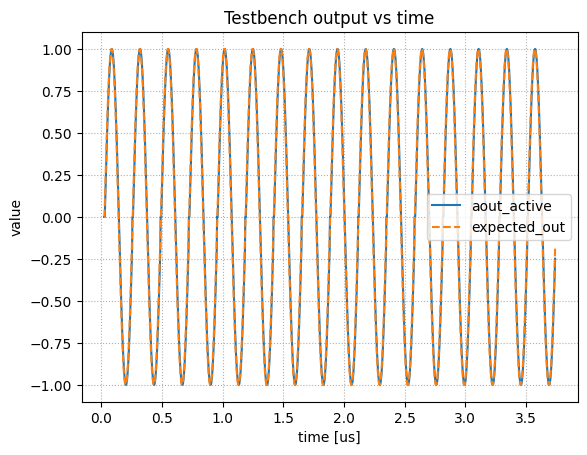

In [8]:
dac_model_dir = REPO_ROOT / "models" / "Dac"

csv_path = emu.run_verilated_mem_tb(
    mem_file=dac_model_dir / "stimulus.mem",            
    verilog_dir=str(dac_model_dir), 
    top_module="dac_top_tb_mem",
    sources=("dac_top_tb_mem.sv", "dac_top.sv", "dac.sv"),
    build_dir=str(dac_model_dir / "build_tb_mem"),
    log_csv_name="top_dac_mem.csv",
    mem_filename_in_tb="stimulus.mem",
    enable_wave=False
)

emu.plot_tb_csv(
    csv_path, 
    value_cols=("aout_active",), 
    expected_col="expected_out", 
    time_unit="us"
)

In [9]:
prog.print_pmem2hex()

// PMEM content
000000000000000000
8c600000000000000c
dce000c20000000000
4c080000000000d700
8c6000000000000020
dda00030000000d700
dda00034800000d700
dda00035000000d700
dda00010000000dc00
dda00014800000dc00
dda00015000000dc00
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d